In [89]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter
from python_speech_features import mfcc
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
#https://www.kaggle.com/datasets/mozillaorg/common-voice

In [91]:
data= pd.read_csv("cv-invalid.csv")
data=data.dropna(subset=["gender","age"])
data.head()
print(data.shape[0])
print(data["age"].unique())

5841
['twenties' 'thirties' 'sixties' 'fourties' 'teens' 'fifties' 'seventies'
 'eighties']


C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value encountered in divide
  return y / np.max(np.abs(y))
C:\Users\farah\AppData\Local\Temp\ipykernel_18808\605108502.py:10: RuntimeWarning: invalid value enc

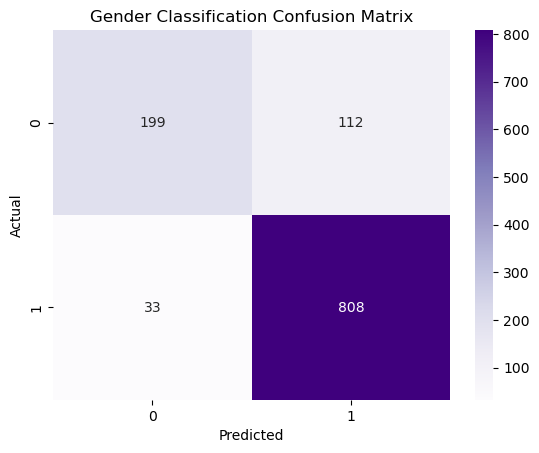

Gender Classification Report:
              precision    recall  f1-score   support

      Female       0.86      0.64      0.73       311
        Male       0.88      0.96      0.92       841

    accuracy                           0.87      1152
   macro avg       0.87      0.80      0.83      1152
weighted avg       0.87      0.87      0.87      1152

Accuracy: 0.5048


In [48]:


# Ambient Noise Reduction (Low-pass filter)
def butter_lowpass_filter(data, cutoff=3000, fs=16000, order=6):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return lfilter(b, a, data)

# Vocal Enhancement (simple gain normalization)
def vocal_enhancement(y):
    return y / np.max(np.abs(y))

# Feature Extraction Function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=16000)
    
    # Audio Trimming
    y, _ = librosa.effects.trim(y)

    # Ambient Noise Reduction
    y = butter_lowpass_filter(y, fs=sr)

    # Vocal Enhancement
    y = vocal_enhancement(y)

    # Audio Framing and Splitting
    frame_length = 2048
    hop_length = 512
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)

    # Feature Extraction
    mfcc_feat = mfcc(y, sr, numcep=13)
    stft_feat = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    
    return np.hstack((np.mean(mfcc_feat, axis=0), np.mean(stft_feat, axis=1)))

# Load Dataset (Common Voice)
dataset_path = "cv-invalid"
newdata = []
gender_labels = []
age_labels = []

age_encoder=LabelEncoder()
age_encoder.fit(data["age"].unique())
for index,row in data.iterrows() :  
    if row["filename"].endswith(".mp3"):
        try:
            features = extract_features(row["filename"])
            gender = row["gender"]  # 'male' or 'female'
            age = row["age"]  # numerical age

            newdata.append(features)
            gender_labels.append(1 if gender == 'male' else 0)
            age_labels.append(age_encoder.transform([age])[0])
        except Exception as e:
            continue
            #print(f"Error processing {row["filename"]}: {e}")

# Convert to NumPy Arrays
newdata = np.array(newdata)
gender_labels = np.array(gender_labels)
age_labels = np.array(age_labels)


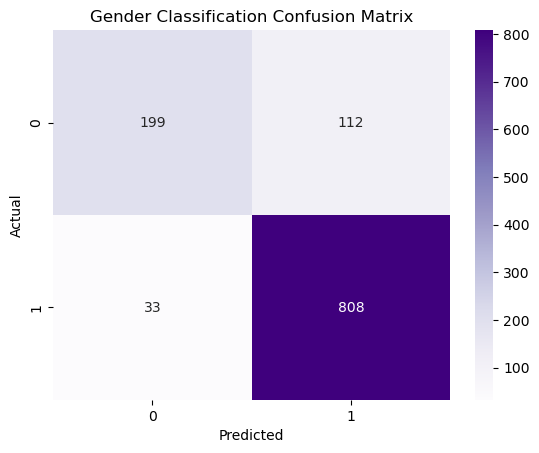

Gender Classification Report:
              precision    recall  f1-score   support

      Female       0.86      0.64      0.73       311
        Male       0.88      0.96      0.92       841

    accuracy                           0.87      1152
   macro avg       0.87      0.80      0.83      1152
weighted avg       0.87      0.87      0.87      1152

Accuracy: 0.8741


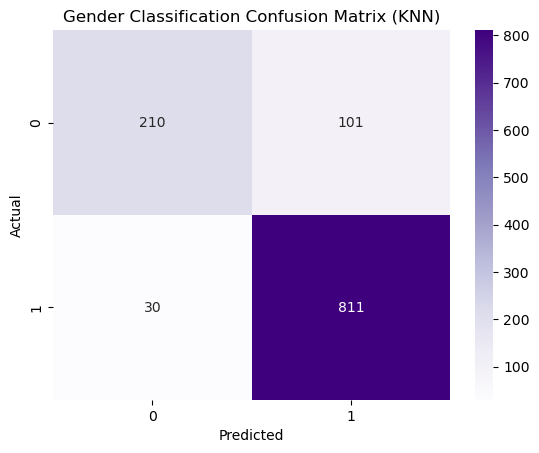

Gender Classification Report (KNN):
              precision    recall  f1-score   support

      Female       0.88      0.68      0.76       311
        Male       0.89      0.96      0.93       841

    accuracy                           0.89      1152
   macro avg       0.88      0.82      0.84      1152
weighted avg       0.89      0.89      0.88      1152

Accuracy (KNN): 0.8863


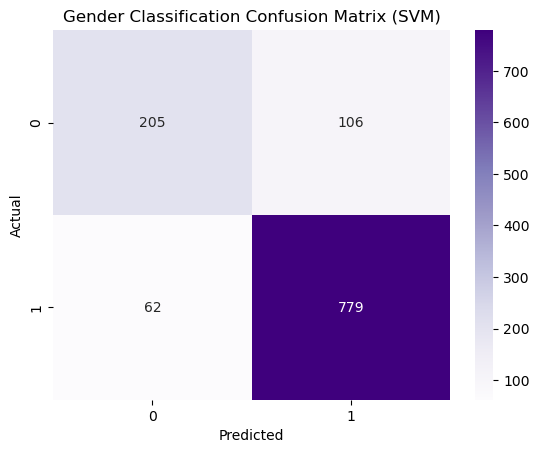

Gender Classification Report (SVM):
              precision    recall  f1-score   support

      Female       0.77      0.66      0.71       311
        Male       0.88      0.93      0.90       841

    accuracy                           0.85      1152
   macro avg       0.82      0.79      0.81      1152
weighted avg       0.85      0.85      0.85      1152

Accuracy (SVM): 0.8542


In [93]:
# Split Data for Gender Classification
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(newdata, gender_labels, test_size=0.2, random_state=42)
# Train Random Forest for Gender
gender_model = RandomForestClassifier(n_estimators=100, random_state=42)
gender_model.fit(X_train_g, y_train_g)
y_pred_g = gender_model.predict(X_test_g)

# Confusion Matrix for Gender
cm_g = confusion_matrix(y_test_g, y_pred_g)
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Gender Classification Report:")
print(classification_report(y_test_g, y_pred_g, target_names=['Female', 'Male']))
accuracy = accuracy_score(y_test_g, y_pred_g)
# Print accuracy
print(f'Accuracy: {accuracy:.4f}')
# Plot Confusion Matrix for Age (discretize age into bins)
##################################################################################################################################
# Train KNN for Gender
# Use KNeighborsClassifier instead of RandomForest
gender_model_knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors
gender_model_knn.fit(X_train_g, y_train_g)

# Make predictions
y_pred_g_knn = gender_model_knn.predict(X_test_g)

# Confusion Matrix for Gender
cm_g_knn = confusion_matrix(y_test_g, y_pred_g_knn)
sns.heatmap(cm_g_knn, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Gender Classification Report (KNN):")
print(classification_report(y_test_g, y_pred_g_knn, target_names=['Female', 'Male']))

# Calculate accuracy
accuracy_knn = accuracy_score(y_test_g, y_pred_g_knn)
# Print accuracy
print(f'Accuracy (KNN): {accuracy_knn:.4f}')
###################################################################################################################################
# Train SVM for Gender
# Use SVC (Support Vector Classifier)
gender_model_svm = SVC(kernel='linear', random_state=42)  # You can adjust the kernel as needed
gender_model_svm.fit(X_train_g, y_train_g)

# Make predictions
y_pred_g_svm = gender_model_svm.predict(X_test_g)

# Confusion Matrix for Gender
cm_g_svm = confusion_matrix(y_test_g, y_pred_g_svm)
sns.heatmap(cm_g_svm, annot=True, fmt='d', cmap='Purples')
plt.title('Gender Classification Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Gender Classification Report
print("Gender Classification Report (SVM):")
print(classification_report(y_test_g, y_pred_g_svm, target_names=['Female', 'Male']))

# Calculate accuracy
accuracy_svm = accuracy_score(y_test_g, y_pred_g_svm)

# Print accuracy
print(f'Accuracy (SVM): {accuracy_svm:.4f}')


['twenties' 'thirties' 'sixties' 'fourties' 'teens' 'fifties' 'seventies'
 'eighties']
[0 1 2 3 4 5 6 7]
['<18', '30-40', '20-30', '70-80', '70-80', ..., '70-80', '50-60', '<18', '70-80', '20-30']
Length: 1152
Categories (7, object): ['20-30' < '30-40' < '60-70' < '40-50' < '<18' < '50-60' < '70-80']
['70-80', '70-80', '20-30', '70-80', '70-80', ..., '70-80', '70-80', '70-80', '70-80', '20-30']
Length: 1152
Categories (7, object): ['20-30' < '30-40' < '60-70' < '40-50' < '<18' < '50-60' < '70-80']
0


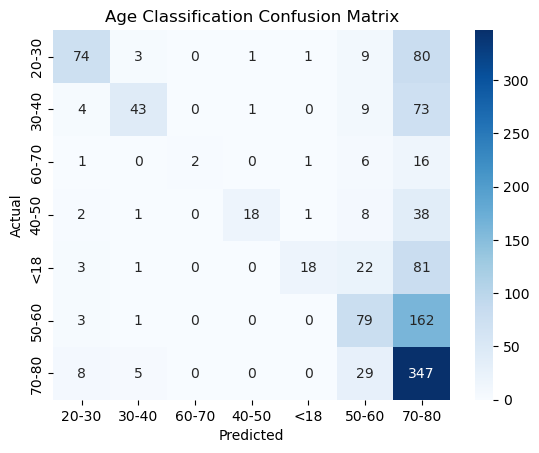

Age Classification Report:
              precision    recall  f1-score   support

       20-30       0.78      0.44      0.56       168
       30-40       0.80      0.33      0.47       130
       60-70       0.90      0.26      0.41        68
       40-50       0.49      0.32      0.39       245
         <18       1.00      0.08      0.14        26
       50-60       0.44      0.89      0.59       389
       70-80       0.86      0.14      0.25       125

    accuracy                           0.50      1151
   macro avg       0.75      0.35      0.40      1151
weighted avg       0.62      0.50      0.47      1151

Accuracy: 0.5048
[0 1 2 3 4 5 6 7]


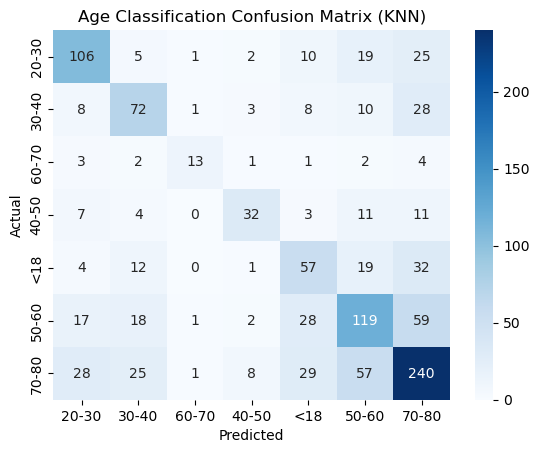

Age Classification Report (KNN):
              precision    recall  f1-score   support

       20-30       0.61      0.63      0.62       168
       30-40       0.52      0.55      0.54       130
       60-70       0.65      0.47      0.55        68
       40-50       0.50      0.49      0.49       245
         <18       0.76      0.50      0.60        26
       50-60       0.60      0.62      0.61       389
       70-80       0.42      0.46      0.44       125
         +80       0.00      0.00      0.00         0

    accuracy                           0.56      1151
   macro avg       0.51      0.46      0.48      1151
weighted avg       0.56      0.56      0.56      1151

Accuracy (KNN): 0.5552


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


['twenties' 'thirties' 'sixties' 'fourties' 'teens' 'fifties' 'seventies'
 'eighties']
[0 1 2 3 4 5 6 7]
['<18', '30-40', '20-30', '70-80', '70-80', ..., '70-80', '50-60', '<18', '70-80', '20-30']
Length: 1152
Categories (7, object): ['20-30' < '30-40' < '60-70' < '40-50' < '<18' < '50-60' < '70-80']
['70-80', '70-80', '20-30', '70-80', '70-80', ..., '70-80', '70-80', '70-80', '30-40', '20-30']
Length: 1152
Categories (7, object): ['20-30' < '30-40' < '60-70' < '40-50' < '<18' < '50-60' < '70-80']
6


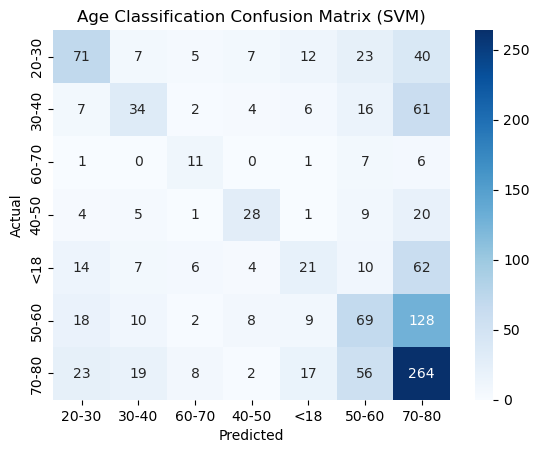

Age Classification Report (SVM):
              precision    recall  f1-score   support

       20-30       0.51      0.42      0.46       168
       30-40       0.41      0.26      0.32       130
       60-70       0.53      0.41      0.46        68
       40-50       0.36      0.28      0.32       245
         <18       0.31      0.42      0.36        26
       50-60       0.45      0.68      0.54       389
       70-80       0.31      0.17      0.22       125
         +80       0.00      0.00      0.00         0

    accuracy                           0.43      1151
   macro avg       0.36      0.33      0.34      1151
weighted avg       0.43      0.43      0.41      1151

Accuracy (SVM): 0.4327


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [99]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(newdata, age_labels, test_size=0.2, random_state=42)

# Train Random Forest for Age
age_model = RandomForestClassifier(n_estimators=100, random_state=42)
age_model.fit(X_train_a, y_train_a)
y_pred_a = age_model.predict(X_test_a)
age_bins = age_encoder.fit_transform(data["age"].unique())
print(data["age"].unique())
#['twenties' 'thirties' 'sixties' 'fourties' 'teens' 'fifties' 'seventies''eighties']
age_bins.sort()
print(age_bins)
age_labels_str = ['20-30','30-40' ,'60-70' ,'40-50' ,'<18' ,'50-60' ,'70-80']
#age_labels_str = age_encoder.fit_transform(data["age"].unique()) 
y_test_binned = pd.cut(y_test_a, bins=age_bins, labels=age_labels_str)
print(y_test_binned)
valid_mask = ~y_test_binned.isna()
y_pred_binned = pd.cut(y_pred_a, bins=age_bins, labels=age_labels_str)
print(y_pred_binned)
print(y_pred_binned.isna().sum())
y_test_binned = y_test_binned[valid_mask]
y_pred_binned = y_pred_binned[valid_mask]
cm_a = confusion_matrix(y_test_binned, y_pred_binned, labels=age_labels_str)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Age Classification Report:")
print(classification_report(y_test_binned, y_pred_binned, target_names=age_labels_str))
accuracy = accuracy_score(y_test_binned, y_pred_binned)

# Print accuracy
print(f'Accuracy: {accuracy:.4f}')
#################################################################################################################################################################################################################
# Use KNeighborsClassifier instead of RandomForest
age_model_knn = KNeighborsClassifier(n_neighbors=5)  # Adjust the number of neighbors as needed
age_model_knn.fit(X_train_a, y_train_a)

# Make predictions
y_pred_a_knn = age_model_knn.predict(X_test_a)

# Binning age for evaluation (discretize the predicted and true age labels)
age_bins = np.sort(age_encoder.fit_transform(data["age"].unique()))
print(age_bins)

age_labels_str = ['20-30','30-40' ,'60-70' ,'40-50' ,'<18' ,'50-60' ,'70-80']
y_test_binned = pd.cut(y_test_a, bins=age_bins, labels=age_labels_str)
y_pred_binned = pd.cut(y_pred_a_knn, bins=age_bins, labels=age_labels_str)

# Remove NaN values in y_test_binned and y_pred_binned
valid_mask = ~y_test_binned.isna()
y_test_binned = y_test_binned[valid_mask]
y_pred_binned = y_pred_binned[valid_mask]
y_test_binned = y_test_binned.astype(str)
y_pred_binned = y_pred_binned.astype(str)

# Confusion Matrix for Age (KNN)
cm_a_knn = confusion_matrix(y_test_binned, y_pred_binned, labels=age_labels_str)
sns.heatmap(cm_a_knn, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Age (KNN)
print("Age Classification Report (KNN):")
age_labels_str.append('+80')
print(classification_report(y_test_binned, y_pred_binned, target_names=age_labels_str))

# Calculate accuracy
accuracy_knn = accuracy_score(y_test_binned, y_pred_binned)

# Print accuracy
print(f'Accuracy (KNN): {accuracy_knn:.4f}')
################################################################################################################################################################################################################## 
age_model = SVC(kernel='linear', random_state=42)  # You can adjust the kernel as needed
age_model.fit(X_train_a, y_train_a)

# Make predictions
y_pred_a = age_model.predict(X_test_a)

# Define age bins and labels
age_bins = age_encoder.fit_transform(data["age"].unique())
print(data["age"].unique())
age_bins.sort()
print(age_bins)
age_labels_str = ['20-30', '30-40', '60-70', '40-50', '<18', '50-60', '70-80']

# Binning y_test and y_pred based on age_bins
y_test_binned = pd.cut(y_test_a, bins=age_bins, labels=age_labels_str)
print(y_test_binned)
valid_mask = ~y_test_binned.isna()

# Binning y_pred based on age_bins
y_pred_binned = pd.cut(y_pred_a, bins=age_bins, labels=age_labels_str)
print(y_pred_binned)
print(y_pred_binned.isna().sum())

# Filter out invalid predictions and true values
y_test_binned = y_test_binned[valid_mask]
y_pred_binned = y_pred_binned[valid_mask]
y_test_binned = y_test_binned.astype(str)
y_pred_binned = y_pred_binned.astype(str)

# Confusion Matrix for Age Classification
cm_a = confusion_matrix(y_test_binned, y_pred_binned, labels=age_labels_str)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', xticklabels=age_labels_str, yticklabels=age_labels_str)
plt.title('Age Classification Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Age Classification Report
print("Age Classification Report (SVM):")
age_labels_str.append('+80')
print(classification_report(y_test_binned, y_pred_binned, target_names=age_labels_str))

# Calculate accuracy
accuracy = accuracy_score(y_test_binned, y_pred_binned)

# Print accuracy
print(f'Accuracy (SVM): {accuracy:.4f}')